
Exp 12. Implement L1 (Lasso) and L2 (Ridge) regularization on the given Melbourne
House Price Dataset.



In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import Lasso, Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
data = pd.read_csv("/content/drive/MyDrive/python-ml-lab/exp_11_12/dataset_Melbourne_housing_FULL_exp_12.csv")
data.head()

,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,...,Bathroom,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount
0,Abbotsford,68 Studley St,2,h,NaN,SS,Jellis,3/09/2016,2.5,3067.0,...,1.0,1.0,126.0,NaN,NaN,Yarra City Council,-37.8014,144.9958,Northern Metropolitan,4019.0
1,Abbotsford,85 Turner St,2,h,1480000.0,S,Biggin,3/12/2016,2.5,3067.0,...,1.0,1.0,202.0,NaN,NaN,Yarra City Council,-37.7996,144.9984,Northern Metropolitan,4019.0
2,Abbotsford,25 Bloomburg St,2,h,1035000.0,S,Biggin,4/02/2016,2.5,3067.0,...,1.0,0.0,156.0,79.0,1900.0,Yarra City Council,-37.8079,144.9934,Northern Metropolitan,4019.0
3,Abbotsford,18/659 Victoria St,3,u,NaN,VB,Rounds,4/02/2016,2.5,3067.0,...,2.0,1.0,0.0,NaN,NaN,Yarra City Council,-37.8114,145.0116,Northern Metropolitan,4019.0
4,Abbotsford,5 Charles St,3,h,1465000.0,SP,Biggin,4/03/2017,2.5,3067.0,...,2.0,0.0,134.0,150.0,1900.0,Yarra City Council,-37.8093,144.9944,Northern Metropolitan,4019.0


In [ ]:
data.shape

(34857, 21)

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34857 entries, 0 to 34856
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Suburb         34857 non-null  object 
 1   Address        34857 non-null  object 
 2   Rooms          34857 non-null  int64  
 3   Type           34857 non-null  object 
 4   Price          27247 non-null  float64
 5   Method         34857 non-null  object 
 6   SellerG        34857 non-null  object 
 7   Date           34857 non-null  object 
 8   Distance       34856 non-null  float64
 9   Postcode       34856 non-null  float64
 10  Bedroom2       26640 non-null  float64
 11  Bathroom       26631 non-null  float64
 12  Car            26129 non-null  float64
 13  Landsize       23047 non-null  float64
 14  BuildingArea   13742 non-null  float64
 15  YearBuilt      15551 non-null  float64
 16  CouncilArea    34854 non-null  object 
 17  Lattitude      26881 non-null  float64
 18  Longti

In [ ]:
data.isnull().sum()

,0
Suburb,0
Address,0
Rooms,0
Type,0
Price,7610
Method,0
SellerG,0
Date,0
Distance,1
Postcode,1


In [ ]:
# Drop rows where target is missing
data = data.dropna(subset=['Price'])

# Fill numerical missing values with median
num_cols = data.select_dtypes(include=['float64', 'int64']).columns
data[num_cols] = data[num_cols].fillna(data[num_cols].median())

# Fill categorical missing values with mode
cat_cols = data.select_dtypes(include=['object']).columns
for col in cat_cols:
    data[col] = data[col].fillna(data[col].mode()[0])

In [ ]:
# Drop high-cardinality categorical features that cause memory issues
data = data.drop(['Address', 'Date'], axis=1)

data = pd.get_dummies(data, drop_first=True)

In [ ]:
X = data.drop('Price', axis=1)
y = data['Price']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
#Apply Lasso (L1 Regularization)
lasso = Lasso(alpha=0.1)
lasso.fit(X_train_scaled, y_train)

y_pred_lasso = lasso.predict(X_test_scaled)

print("Lasso Results:")
print("MSE:", mean_squared_error(y_test, y_pred_lasso))
print("R2 Score:", r2_score(y_test, y_pred_lasso))

Lasso Results:
MSE: 148352325393.90524
R2 Score: 0.6528224744097904


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.361e+15, tolerance: 8.882e+11
  model = cd_fast.enet_coordinate_descent(


In [ ]:
# Apply Ridge (L2 Regularization)
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train)

y_pred_ridge = ridge.predict(X_test_scaled)

print("\nRidge Results:")
print("MSE:", mean_squared_error(y_test, y_pred_ridge))
print("R2 Score:", r2_score(y_test, y_pred_ridge))


Ridge Results:
MSE: 148197456920.60248
R2 Score: 0.6531849011746585


In [ ]:
lasso_coeff = pd.Series(lasso.coef_, index=X.columns)
ridge_coeff = pd.Series(ridge.coef_, index=X.columns)

print("\nNumber of features used by Lasso:", sum(lasso_coeff != 0))
print("Number of features used by Ridge:", len(ridge_coeff))


Number of features used by Lasso: 723
Number of features used by Ridge: 749


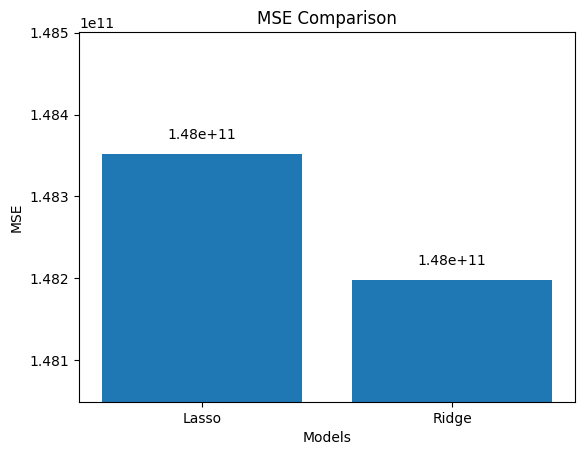

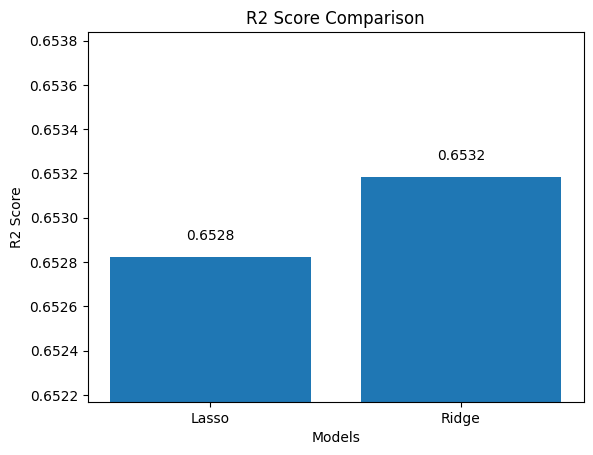

In [ ]:
import matplotlib.pyplot as plt

models = ['Lasso', 'Ridge']
mse_values = [
    mean_squared_error(y_test, y_pred_lasso),
    mean_squared_error(y_test, y_pred_ridge)
]

r2_values = [
    r2_score(y_test, y_pred_lasso),
    r2_score(y_test, y_pred_ridge)
]

# MSE Plot
plt.figure()
bars_mse = plt.bar(models, mse_values)
plt.title("MSE Comparison")
plt.xlabel("Models")
plt.ylabel("MSE")

min_mse = min(mse_values)
max_mse = max(mse_values)
plt.ylim(min_mse * 0.999, max_mse * 1.001)
for bar in bars_mse:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + (max_mse * 0.0001), f'{yval:.2e}', ha='center', va='bottom')
plt.show()

# R2 Plot
plt.figure()
bars_r2 = plt.bar(models, r2_values)
plt.title("R2 Score Comparison")
plt.xlabel("Models")
plt.ylabel("R2 Score")

min_r2 = min(r2_values)
max_r2 = max(r2_values)
plt.ylim(min_r2 * 0.999, max_r2 * 1.001)
for bar in bars_r2:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + (max_r2 * 0.0001), f'{yval:.4f}', ha='center', va='bottom')
plt.show()

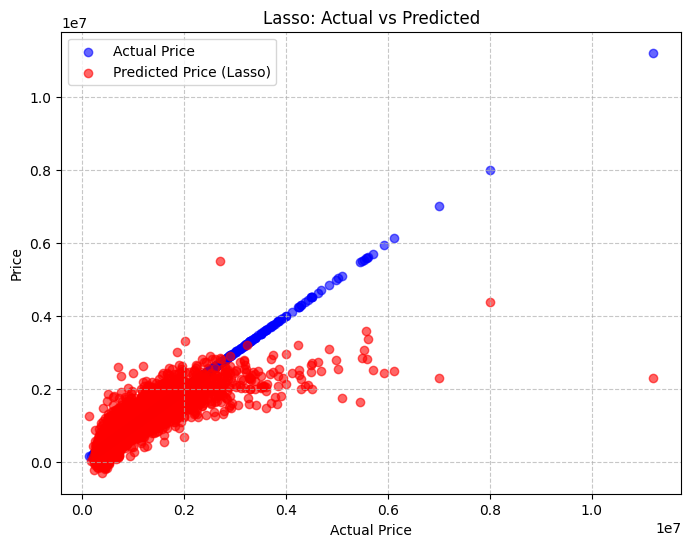

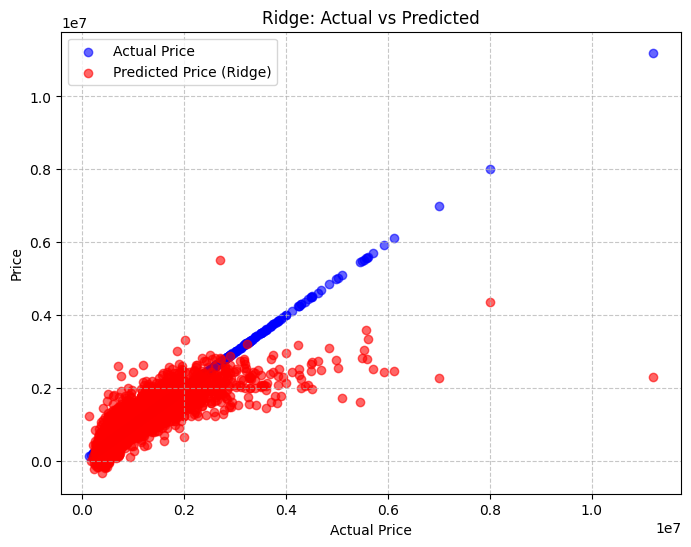

In [ ]:
# Lasso
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_test, color='blue', label='Actual Price', alpha=0.6)
plt.scatter(y_test, y_pred_lasso, color='red', label='Predicted Price (Lasso)', alpha=0.6)
plt.title("Lasso: Actual vs Predicted")
plt.xlabel("Actual Price")
plt.ylabel("Price")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# Ridge
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_test, color='blue', label='Actual Price', alpha=0.6)
plt.scatter(y_test, y_pred_ridge, color='red', label='Predicted Price (Ridge)', alpha=0.6)
plt.title("Ridge: Actual vs Predicted")
plt.xlabel("Actual Price")
plt.ylabel("Price")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [ ]:
comparison = pd.DataFrame({
    'Model': ['Lasso', 'Ridge'],
    'MSE': mse_values,
    'R2 Score': r2_values
})

print(comparison)

   Model           MSE  R2 Score
0  Lasso  1.483523e+11  0.652822
1  Ridge  1.481975e+11  0.653185


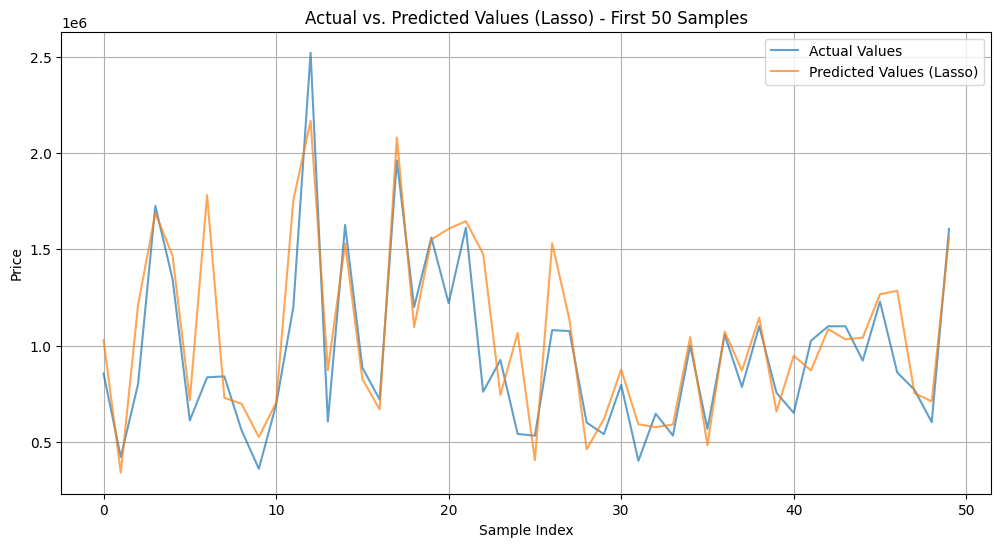

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(y_test.values[:50], label='Actual Values', alpha=0.7)
plt.plot(y_pred_lasso[:50], label='Predicted Values (Lasso)', alpha=0.7)
plt.title('Actual vs. Predicted Values (Lasso) - First 50 Samples')
plt.xlabel('Sample Index')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.show()

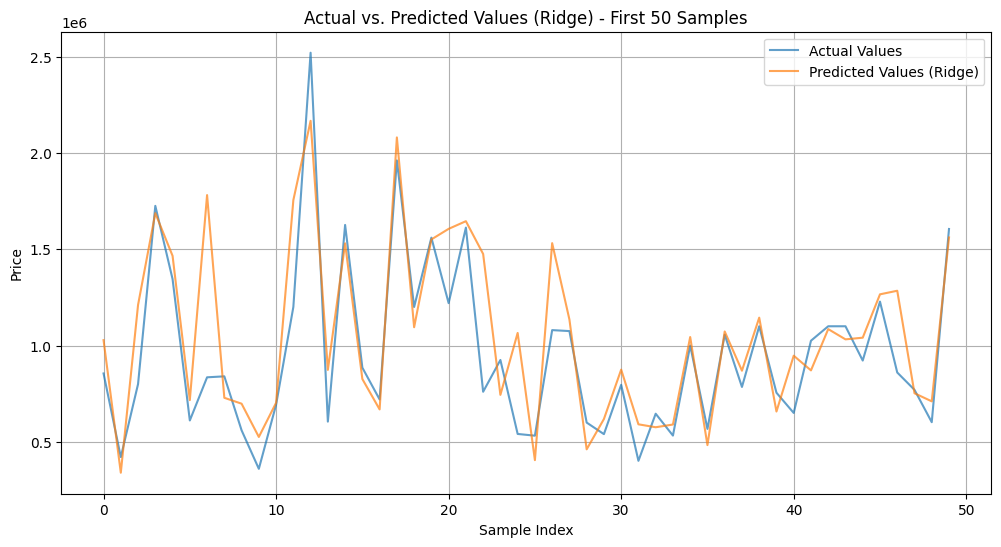

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(y_test.values[:50], label='Actual Values', alpha=0.7)
plt.plot(y_pred_ridge[:50], label='Predicted Values (Ridge)', alpha=0.7)
plt.title('Actual vs. Predicted Values (Ridge) - First 50 Samples')
plt.xlabel('Sample Index')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
import pickle

# Save Lasso Model
with open('lasso_model.pkl', 'wb') as f:
    pickle.dump(lasso, f)

# Save Ridge Model
with open('ridge_model.pkl', 'wb') as f:
    pickle.dump(ridge, f)

# Save Scaler (VERY IMPORTANT)
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print("Models and scaler saved successfully!")

Models and scaler saved successfully!
